In [1]:
from math_verify import parse,verify
from datasets import load_dataset
import json
from tqdm import tqdm

/data/MaoXiaowei/models/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [141]:
res=[]
with open("outputs/amc23_rkv_a02.jsonl", "r") as f:
    for line in f:
        data = json.loads(line)
        res.append(data)
len(res)

1280

In [63]:
res=res[:640]

In [142]:
budget = 256
count = 0
probs = []
for i in tqdm(range(len(res))):
    a1=parse("\\boxed{" + res[i]["answer"] + "}", parsing_timeout=3)
    a2=parse(res[i]["output"], parsing_timeout=3)
    if verify(a1,a2,timeout_seconds=1):
        count += 1
        if res[i]["output_tokens"] > budget:
            probs.append(budget / res[i]["output_tokens"])
        else:
            probs.append(1)
print("pass@1: ", count / len(res))
print("compress ratio: ", sum(probs) / len(probs))

  0%|          | 0/1280 [00:00<?, ?it/s]

100%|██████████| 1280/1280 [00:14<00:00, 86.60it/s] 

pass@1:  0.3984375
compress ratio:  0.08110251015854858


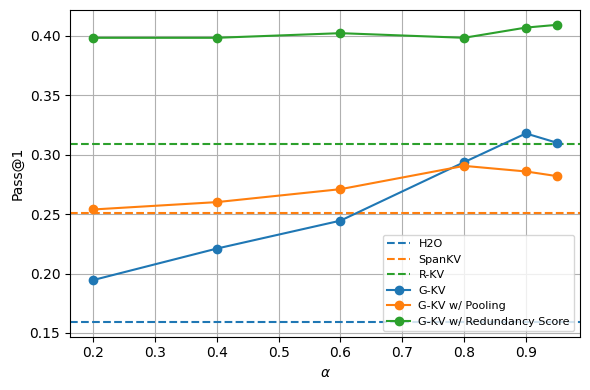

In [166]:
import matplotlib.pyplot as plt

# 数据
alpha = [0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95]
h2o_max = [0.1593, 0.1945, 0.2210, 0.2445, 0.2937, 0.3179, 0.3101]
h2o_mean = [0.1593, 0.1906, 0.2421, 0.2476, 0.2515, 0.2585, 0.2656]
spankv_max = [0.2507, 0.2539, 0.2601, 0.2710, 0.2906, 0.2859, 0.2820]
rkv_max = [0.3093, 0.3984, 0.3984, 0.4023, 0.3984, 0.4070, 0.4093]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

# 绘图
plt.figure(figsize=(6, 4))

plt.axhline(y=h2o_max[0], color=colors[0], linestyle="--", label="H2O")
plt.axhline(y=spankv_max[0], color=colors[1], linestyle="--", label="SpanKV")
plt.axhline(y=rkv_max[0], color=colors[2], linestyle="--", label="R-KV")

plt.plot(alpha[1:], h2o_max[1:], marker="o", label="G-KV")
plt.plot(alpha[1:], spankv_max[1:], marker="o", label="G-KV w/ Pooling")
plt.plot(alpha[1:], rkv_max[1:], marker="o", label="G-KV w/ Redundancy Score")

# 图形设置
# plt.title("Performance vs Alpha")
plt.xlabel("$\\alpha$")
plt.ylabel("Pass@1")
plt.grid(True)
plt.legend( fontsize=8)
plt.tight_layout()
plt.savefig("pdf/amc23_pass_at_1.pdf", format="pdf")

# 显示图像
plt.show()

In [106]:
# mean token length
lens=[res[i]['output_tokens'] for i in range(len(res))]
print(f'mean token length: {sum(lens)/len(lens):.2f}')
print(f'max token length: {max(lens)}')
print(f'min token length: {min(lens)}')

mean token length: 10042.33
max token length: 16286
min token length: 777


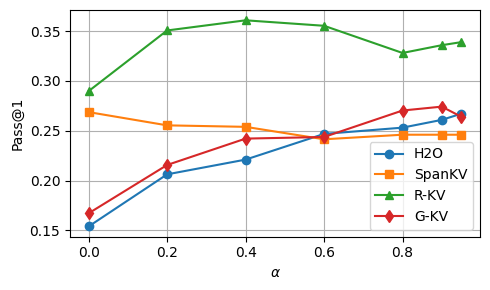

In [223]:
import matplotlib.pyplot as plt

# 数据
alpha = [0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95]
H2O =    [0.1539, 0.2062, 0.2210, 0.2468, 0.2531, 0.2609, 0.2671]
SpanKV = [0.2687, 0.2554, 0.2539, 0.2414, 0.2460, 0.2460, 0.2460]
RKV =    [0.2898, 0.3507, 0.3609, 0.3554, 0.3281, 0.3359, 0.3390]
GKV =    [0.1671, 0.2156, 0.2421, 0.2437, 0.2703, 0.2742, 0.2640]

# 画图
plt.figure(figsize=(5, 3))
plt.plot(alpha, H2O, marker='o', label='H2O')
plt.plot(alpha, SpanKV, marker='s', label='SpanKV')
plt.plot(alpha, RKV, marker='^', label='R-KV')
plt.plot(alpha, GKV, marker='d', label='G-KV')

# 图形设置
# plt.title('Performance vs. Alpha')
plt.xlabel('$\\alpha$')
plt.ylabel('Pass@1')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("performance.pdf",format="pdf")
plt.show()

# AIME 24

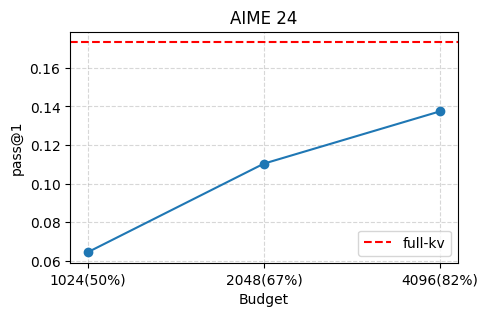

In [34]:
import matplotlib.pyplot as plt

y = [0.0645, 0.1104, 0.1375]
h_line = 0.1733

# 使横轴为类别型，数据点间距相等
x_labels = ['1024(50%)', '2048(67%)', '4096(82%)']
x_pos = range(len(y))

plt.figure(figsize=(5, 3))
plt.axhline(y=h_line, color='r', linestyle='--', label='full-kv')
plt.plot(x_pos, y, marker='o', linestyle='-')
plt.xticks(x_pos, x_labels)
plt.xlabel('Budget')
plt.ylabel('pass@1')
plt.title('AIME 24')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


In [1]:
import torch
mask = torch.triu(torch.ones(3, 3), diagonal=1).bool()

In [2]:
mask

tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])